<a href="https://colab.research.google.com/github/brittanybee-alt/DataScienceGuidedCapstone/blob/master/Data_Wrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [116]:
ski_data = pd.read_csv('/ski_resort_data.csv')

In [117]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [118]:
ski_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               330 non-null    object 
 1   Region             330 non-null    object 
 2   state              330 non-null    object 
 3   summit_elev        330 non-null    int64  
 4   vertical_drop      330 non-null    int64  
 5   base_elev          330 non-null    int64  
 6   trams              330 non-null    int64  
 7   fastEight          164 non-null    float64
 8   fastSixes          330 non-null    int64  
 9   fastQuads          330 non-null    int64  
 10  quad               330 non-null    int64  
 11  triple             330 non-null    int64  
 12  double             330 non-null    int64  
 13  surface            330 non-null    int64  
 14  total_chairs       330 non-null    int64  
 15  Runs               326 non-null    float64
 16  TerrainParks       279 non

In [119]:
ski_data.head()

,Name,Region,state,summit_elev,vertical_drop,base_elev,trams,fastEight,fastSixes,fastQuads,...,LongestRun_mi,SkiableTerrain_ac,Snow Making_ac,daysOpenLastYear,yearsOpen,averageSnowfall,AdultWeekday,AdultWeekend,projectedDaysOpen,NightSkiing_ac
0,Alyeska Resort,Alaska,Alaska,3939,2500,250,1,0.0,0,2,...,1.0,1610.0,113.0,150.0,60.0,669.0,65.0,85.0,150.0,550.0
1,Eaglecrest Ski Area,Alaska,Alaska,2600,1540,1200,0,0.0,0,0,...,2.0,640.0,60.0,45.0,44.0,350.0,47.0,53.0,90.0,NaN
2,Hilltop Ski Area,Alaska,Alaska,2090,294,1796,0,0.0,0,0,...,1.0,30.0,30.0,150.0,36.0,69.0,30.0,34.0,152.0,30.0
3,Arizona Snowbowl,Arizona,Arizona,11500,2300,9200,0,0.0,1,0,...,2.0,777.0,104.0,122.0,81.0,260.0,89.0,89.0,122.0,NaN
4,Sunrise Park Resort,Arizona,Arizona,11100,1800,9200,0,NaN,0,1,...,1.2,800.0,80.0,115.0,49.0,250.0,74.0,78.0,104.0,80.0


In [120]:
ski_data[ski_data.Name == 'Big Mountain Resort'].T

,151
Name,Big Mountain Resort
Region,Montana
state,Montana
summit_elev,6817
vertical_drop,2353
base_elev,4464
trams,0
fastEight,0.0
fastSixes,0
fastQuads,3


In [121]:
missing = pd.concat([ski_data.isnull().sum(), 100 * ski_data.isnull().mean()], axis=1)
missing.columns=['count', '%']
missing.sort_values(by='count')

,count,%
Name,0,0.000000
Region,0,0.000000
state,0,0.000000
summit_elev,0,0.000000
vertical_drop,0,0.000000
base_elev,0,0.000000
trams,0,0.000000
fastSixes,0,0.000000
double,0,0.000000
fastQuads,0,0.000000


In [122]:
ski_data.select_dtypes('object')

,Name,Region,state
0,Alyeska Resort,Alaska,Alaska
1,Eaglecrest Ski Area,Alaska,Alaska
2,Hilltop Ski Area,Alaska,Alaska
3,Arizona Snowbowl,Arizona,Arizona
4,Sunrise Park Resort,Arizona,Arizona
...,...,...,...
325,Meadowlark Ski Lodge,Wyoming,Wyoming
326,Sleeping Giant Ski Resort,Wyoming,Wyoming
327,Snow King Resort,Wyoming,Wyoming
328,Snowy Range Ski & Recreation Area,Wyoming,Wyoming


In [123]:
ski_data['Name'].value_counts(sort=True).head()

,count
Name,
Crystal Mountain,2
Boston Mills,1
Alpine Valley,1
Wolf Ridge Ski Resort,1
Sugar Mountain Resort,1


In [124]:
(ski_data['Name'] + ', ' + ski_data['Region']).value_counts(sort=True).head()

,count
"White Pine Ski Area, Wyoming",1
"Alyeska Resort, Alaska",1
"Eaglecrest Ski Area, Alaska",1
"Hilltop Ski Area, Alaska",1
"Arizona Snowbowl, Arizona",1


In [125]:
(ski_data['Name'] + ', ' + ski_data['state']).value_counts(sort=True).head()

,count
"White Pine Ski Area, Wyoming",1
"Alyeska Resort, Alaska",1
"Eaglecrest Ski Area, Alaska",1
"Hilltop Ski Area, Alaska",1
"Arizona Snowbowl, Arizona",1


In [126]:
ski_data[ski_data['Name'] == 'Crystal Mountain']

,Name,Region,state,summit_elev,vertical_drop,base_elev,trams,fastEight,fastSixes,fastQuads,...,LongestRun_mi,SkiableTerrain_ac,Snow Making_ac,daysOpenLastYear,yearsOpen,averageSnowfall,AdultWeekday,AdultWeekend,projectedDaysOpen,NightSkiing_ac
104,Crystal Mountain,Michigan,Michigan,1132,375,757,0,0.0,0,1,...,0.3,102.0,96.0,120.0,63.0,132.0,54.0,64.0,135.0,56.0
295,Crystal Mountain,Washington,Washington,7012,3100,4400,1,NaN,2,2,...,2.5,2600.0,10.0,NaN,57.0,486.0,99.0,99.0,NaN,NaN


In [127]:
(ski_data.Region != ski_data.state).sum()

np.int64(33)

In [128]:
ski_data['Region'].value_counts()

,count
Region,
New York,33
Michigan,29
Colorado,22
Sierra Nevada,22
Pennsylvania,19
New Hampshire,16
Wisconsin,16
Vermont,15
Minnesota,14


In [129]:
(ski_data[ski_data.Region != ski_data.state].groupby('state')['Region'].value_counts())

state       Region             
California  Sierra Nevada          20
            Northern California     1
Nevada      Sierra Nevada           2
Oregon      Mt. Hood                4
Utah        Salt Lake City          6
Name: count, dtype: int64

In [130]:
ski_data[['Region', 'state']].nunique()

,0
Region,38
state,35


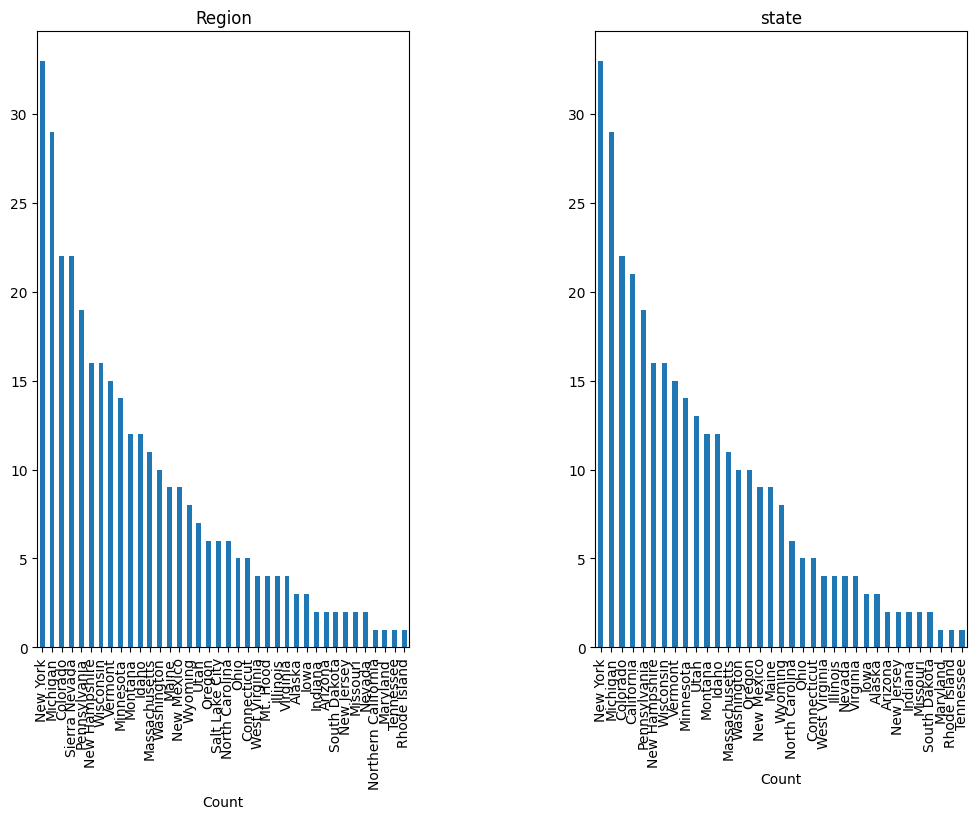

In [131]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8))
ski_data.Region.value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title('Region')
ax[0].set_xlabel('Count')
ski_data.state.value_counts().plot(kind='bar', ax=ax[1])
ax[1].set_title('state')
ax[1].set_xlabel('Count')
plt.subplots_adjust(wspace=0.5)

In [132]:
state_price_means = ski_data.groupby('state')[['AdultWeekday', 'AdultWeekend']].mean()
state_price_means.head()

,AdultWeekday,AdultWeekend
state,,
Alaska,47.333333,57.333333
Arizona,81.500000,83.500000
California,78.214286,81.416667
Colorado,90.714286,90.714286
Connecticut,47.800000,56.800000


Text(0.5, 0, 'Price ($)')

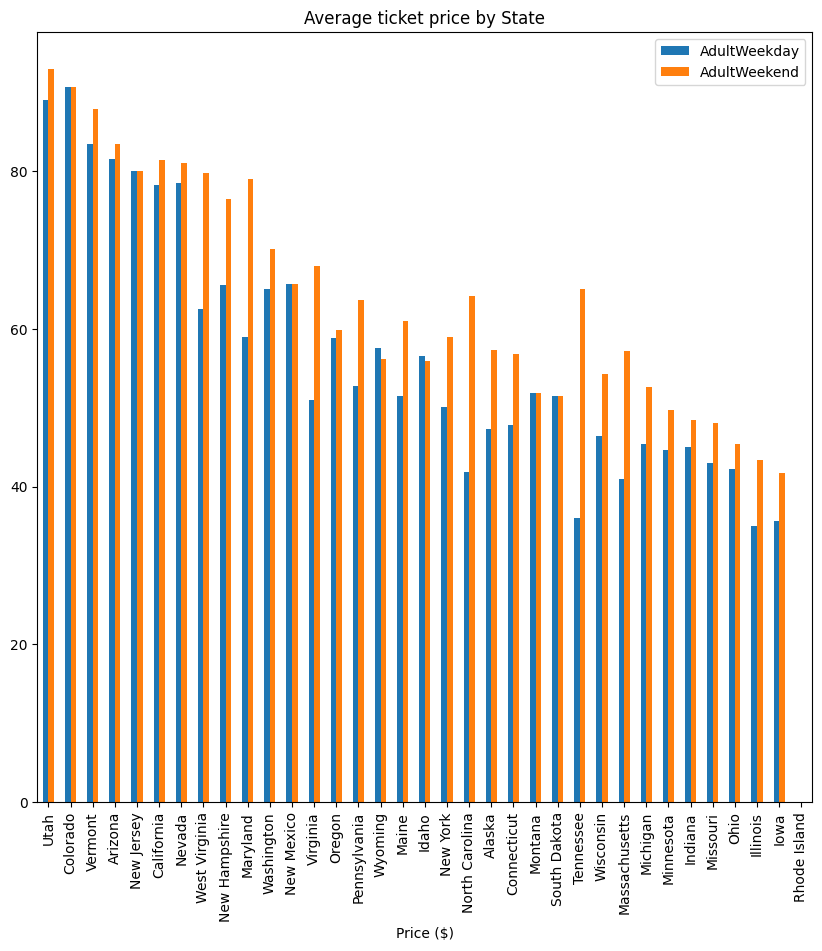

In [133]:
(state_price_means.reindex(index=state_price_means.mean(axis=1).sort_values(ascending=False).index).plot(kind='bar', figsize=(10, 10), title='Average ticket price by State'))
plt.xlabel('Price ($)')

In [134]:
ticket_prices = pd.melt(ski_data[['state', 'AdultWeekday', 'AdultWeekend']], id_vars='state', var_name='Ticket', value_vars=['AdultWeekday', 'AdultWeekend'], value_name='Price')

In [135]:
ticket_prices.head()

,state,Ticket,Price
0,Alaska,AdultWeekday,65.0
1,Alaska,AdultWeekday,47.0
2,Alaska,AdultWeekday,30.0
3,Arizona,AdultWeekday,89.0
4,Arizona,AdultWeekday,74.0


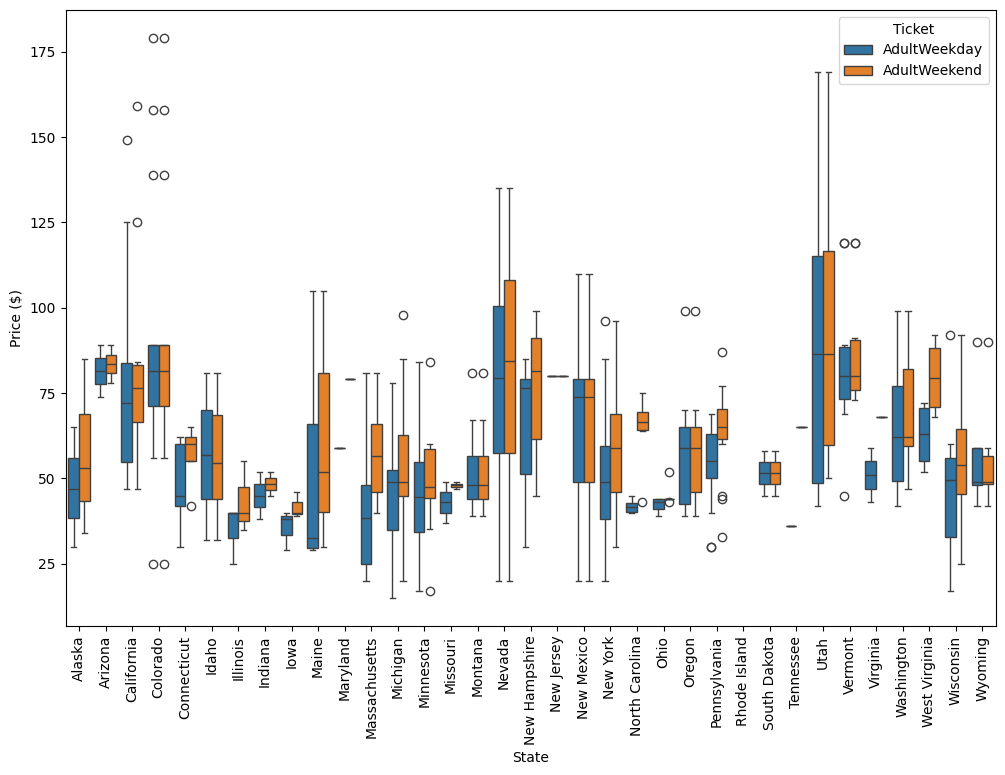

In [136]:
plt.subplots(figsize=(12, 8))
sns.boxplot(x='state', y='Price', hue='Ticket', data=ticket_prices)
plt.xticks(rotation='vertical')
plt.ylabel('Price ($)')
plt.xlabel('State');

In [137]:
ski_data.T.describe

<bound method NDFrame.describe of                               0                    1                 2    \
Name               Alyeska Resort  Eaglecrest Ski Area  Hilltop Ski Area   
Region                     Alaska               Alaska            Alaska   
state                      Alaska               Alaska            Alaska   
summit_elev                  3939                 2600              2090   
vertical_drop                2500                 1540               294   
base_elev                     250                 1200              1796   
trams                           1                    0                 0   
fastEight                     0.0                  0.0               0.0   
fastSixes                       0                    0                 0   
fastQuads                       2                    0                 0   
quad                            2                    0                 0   
triple                          0                    0                 1   
double                          0                    4                 0   
surface                         2                    0                 2   
total_chairs                    7                    4                 3   
Runs                         76.0                 36.0              13.0   
TerrainParks                  2.0                  1.0               1.0   
LongestRun_mi                 1.0                  2.0               1.0   
SkiableTerrain_ac          1610.0                640.0              30.0   
Snow Making_ac              113.0                 60.0              30.0   
daysOpenLastYear            150.0                 45.0             150.0   
yearsOpen                    60.0                 44.0              36.0   
averageSnowfall             669.0                350.0              69.0   
AdultWeekday                 65.0                 47.0              30.0   
AdultWeekend                 85.0                 53.0              34.0   
projectedDaysOpen           150.0                 90.0             152.0   
NightSkiing_ac              550.0                  NaN              30.0   

                                3                    4    \
Name               Arizona Snowbowl  Sunrise Park Resort   
Region                      Arizona              Arizona   
state                       Arizona              Arizona   
summit_elev                   11500                11100   
vertical_drop                  2300                 1800   
base_elev                      9200                 9200   
trams                             0                    0   
fastEight                       0.0                  NaN   
fastSixes                         1                    0   
fastQuads                         0                    1   
quad                              2                    2   
triple                            2                    3   
double                            1                    1   
surface                           2                    0   
total_chairs                      8                    7   
Runs                           55.0                 65.0   
TerrainParks                    4.0                  2.0   
LongestRun_mi                   2.0                  1.2   
SkiableTerrain_ac             777.0                800.0   
Snow Making_ac                104.0                 80.0   
daysOpenLastYear              122.0                115.0   
yearsOpen                      81.0                 49.0   
averageSnowfall               260.0                250.0   
AdultWeekday                   89.0                 74.0   
AdultWeekend                   89.0                 78.0   
projectedDaysOpen             122.0                104.0   
NightSkiing_ac                  NaN                 80.0   

                                             5              6    \
Name               Yosemite Ski & Snowboard Area  Bear Mountain   
Region                

In [138]:
missing_price = ski_data[['AdultWeekday', 'AdultWeekend']].isnull().sum(axis=1)
missing_price.value_counts()/len(missing_price) * 100

,count
0,82.424242
2,14.242424
1,3.333333


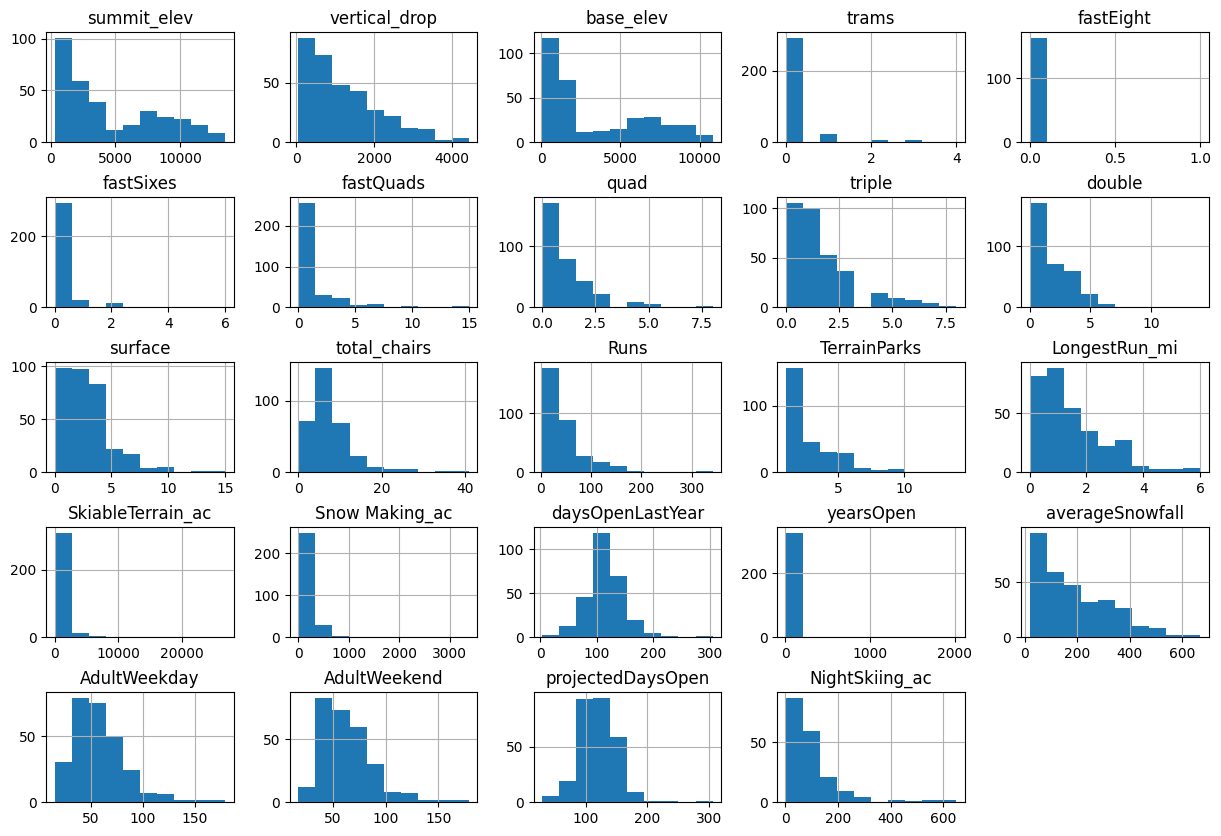

In [139]:
ski_data.hist(figsize=(15, 10))
plt.subplots_adjust(hspace=0.5)

In [140]:
ski_data['SkiableTerrain_ac'][ski_data['SkiableTerrain_ac'] > 10000]

,SkiableTerrain_ac
39,26819.0


In [141]:
ski_data[ski_data['SkiableTerrain_ac'] > 10000].T

,39
Name,Silverton Mountain
Region,Colorado
state,Colorado
summit_elev,13487
vertical_drop,3087
base_elev,10400
trams,0
fastEight,0.0
fastSixes,0
fastQuads,0


In [142]:
ski_data.loc[39, 'SkiableTerrain_ac']

np.float64(26819.0)

In [143]:
ski_data.loc[39, 'SkiableTerrain_ac'] = 1819

In [144]:
ski_data.loc[39, 'SkiableTerrain_ac']

np.float64(1819.0)

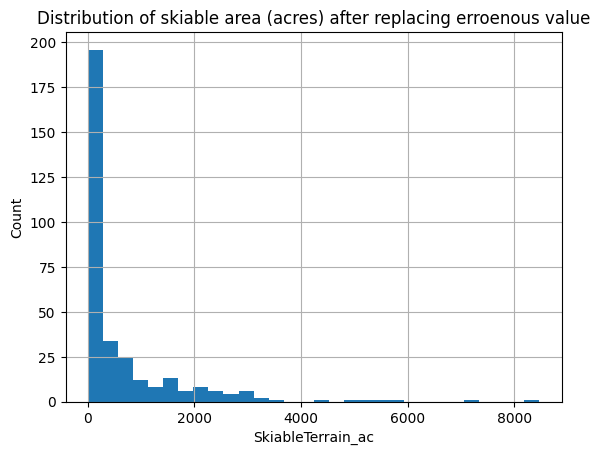

In [145]:
ski_data.SkiableTerrain_ac.hist(bins=30)
plt.xlabel('SkiableTerrain_ac')
plt.ylabel('Count')
plt.title('Distribution of skiable area (acres) after replacing erroenous value');

In [146]:
ski_data['Snow Making_ac'][ski_data['Snow Making_ac'] > 10000]

,Snow Making_ac


In [147]:
ski_data[ski_data['Snow Making_ac'] > 3000].T

,11
Name,Heavenly Mountain Resort
Region,Sierra Nevada
state,California
summit_elev,10067
vertical_drop,3500
base_elev,7170
trams,2
fastEight,0.0
fastSixes,2
fastQuads,7


In [148]:
.6 * 4800

2880.0

In [149]:
ski_data.fastEight.value_counts()

,count
fastEight,
0.0,163
1.0,1


In [150]:
ski_data.drop(columns='fastEight', inplace=True)

In [151]:
ski_data['yearsOpen'][ski_data['yearsOpen'] > 100]

,yearsOpen
34,104.0
115,2019.0


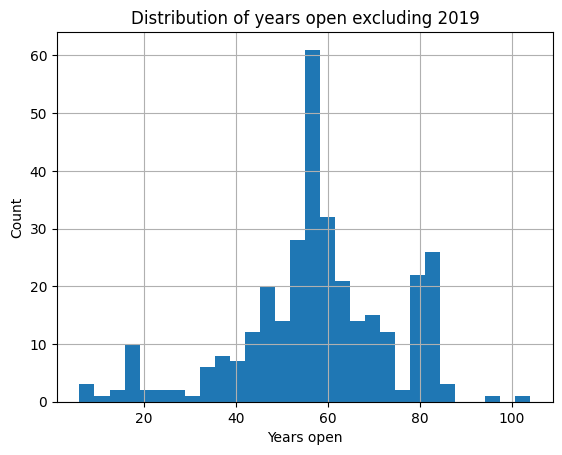

In [152]:
ski_data['yearsOpen'][ski_data['yearsOpen'] < 1000].hist(bins=30)
plt.xlabel('Years open')
plt.ylabel('Count')
plt.title('Distribution of years open excluding 2019');

In [153]:
ski_data['yearsOpen'][ski_data['yearsOpen'] < 1000].describe

<bound method NDFrame.describe of 0      60.0
1      44.0
2      36.0
3      81.0
4      49.0
       ... 
325     9.0
326    81.0
327    80.0
328    59.0
329    81.0
Name: yearsOpen, Length: 328, dtype: float64>

In [154]:
ski_data = ski_data[ski_data['yearsOpen'] < 1000]

In [155]:
state_summary = ski_data.groupby('state').agg(
    resorts_per_state=pd.NamedAgg(column='Name', aggfunc='size'),
    state_total_skiable_area_ac=pd.NamedAgg(column='SkiableTerrain_ac', aggfunc='sum'),
    state_total_days_open=pd.NamedAgg(column='daysOpenLastYear', aggfunc='sum'),
    state_total_terrain_parks=pd.NamedAgg(column='TerrainParks', aggfunc='sum'),
    state_total_nightskiing_ac=pd.NamedAgg(column='NightSkiing_ac', aggfunc='sum')
).reset_index()
state_summary.head()

,state,resorts_per_state,state_total_skiable_area_ac,state_total_days_open,state_total_terrain_parks,state_total_nightskiing_ac
0,Alaska,3,2280.0,345.0,4.0,580.0
1,Arizona,2,1577.0,237.0,6.0,80.0
2,California,21,25948.0,2738.0,81.0,587.0
3,Colorado,22,43682.0,3258.0,74.0,428.0
4,Connecticut,5,358.0,353.0,10.0,256.0


In [156]:
missing_price = ski_data[['AdultWeekend', 'AdultWeekday']].isnull().sum(axis=1)
missing_price.value_counts()/len(missing_price) * 100

,count
0,82.317073
2,14.329268
1,3.353659


In [157]:
ski_data = ski_data[missing_price != 2]

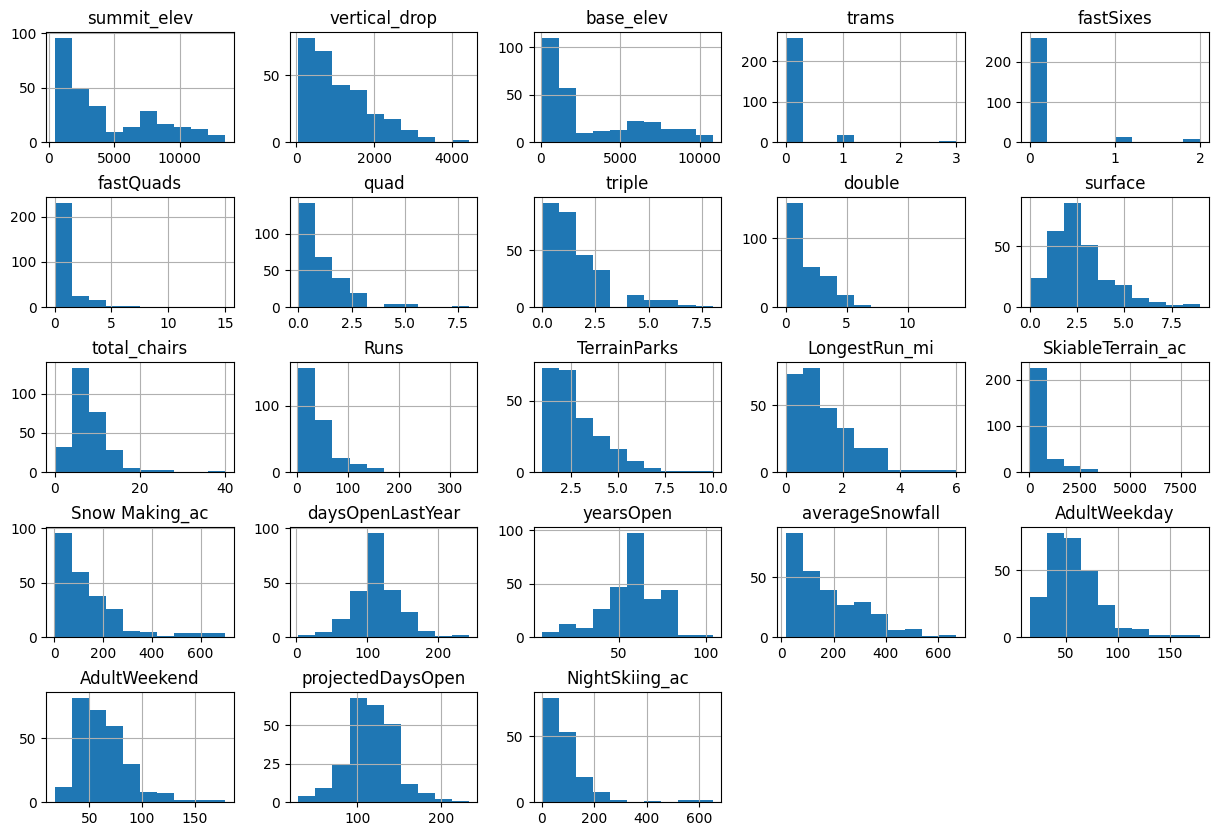

In [158]:
ski_data.hist(figsize=(15, 10))
plt.subplots_adjust(hspace=0.5);

In [159]:
states_url = 'https://simple.wikipedia.org/w/index.php?title=List_of_U.S._states&oldid=7168473'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
usa_states = pd.read_html(states_url, storage_options=headers)

In [160]:
type(usa_states)

list

In [161]:
len(usa_states)

1

In [162]:
usa_states = usa_states[0]
usa_states.head()

Name & postal abbs. [1]                                 Cities               \
  Name & postal abbs. [1] Name & postal abbs. [1].1      Capital   Largest[5]   
0                 Alabama                        AL   Montgomery   Birmingham   
1                  Alaska                        AK       Juneau    Anchorage   
2                 Arizona                        AZ      Phoenix      Phoenix   
3                Arkansas                        AR  Little Rock  Little Rock   
4              California                        CA   Sacramento  Los Angeles   

  Established[A] Population [B][3] Total area[4]          Land area[4]  \
  Established[A] Population [B][3]           mi2      km2          mi2   
0   Dec 14, 1819           4903185         52420   135767        50645   
1    Jan 3, 1959            731545        665384  1723337       570641   
2   Feb 14, 1912           7278717        113990   295234       113594   
3   Jun 15, 1836           3017804         53179   137732        52035   
4    Sep 9, 1850          39512223        163695   423967       155779   

           Water area[4]         Number of Reps.  
       km2           mi2     km2 Number of Reps.  
0   131171          1775    4597               7  
1  1477953         94743  245384               1  
2   294207           396    1026               9  
3   134771          1143    2961               4  
4   403466          7916   20501              53

In [163]:
established = usa_states.iloc[:, 4]

In [164]:
established

,Established[A]
,Established[A]
0,"Dec 14, 1819"
1,"Jan 3, 1959"
2,"Feb 14, 1912"
3,"Jun 15, 1836"
4,"Sep 9, 1850"
5,"Aug 1, 1876"
6,"Jan 9, 1788"
7,"Dec 7, 1787"
8,"Mar 3, 1845"


In [165]:
usa_states_sub = usa_states.iloc[:, [0, 5, 6]].copy()
usa_states_sub.columns = ['state', 'state_population', 'state_area_sq_miles']
usa_states_sub.head()

,state,state_population,state_area_sq_miles
0,Alabama,4903185,52420
1,Alaska,731545,665384
2,Arizona,7278717,113990
3,Arkansas,3017804,53179
4,California,39512223,163695


In [166]:
missing_states = set(state_summary.state) - set(usa_states_sub.state)
missing_states

{'Massachusetts', 'Pennsylvania', 'Rhode Island', 'Virginia'}

In [167]:
usa_states_sub.state[usa_states_sub.state.str.contains('Massachusetts|Pennsylvanina|Rhode Island|Virignia')]

,state
20,Massachusetts[C]
38,Rhode Island[D]


In [168]:
usa_states_sub.state.replace(to_replace='\[.*\]', value='', regex=True, inplace=True)
usa_states_sub.state[usa_states_sub.state.str.contains('Massachusetts|Pennsylvania|Rhode Island|Virginia')]

<>:1: SyntaxWarning: invalid escape sequence '\['
<>:1: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_35153/2909591317.py:1: SyntaxWarning: invalid escape sequence '\['
  usa_states_sub.state.replace(to_replace='\[.*\]', value='', regex=True, inplace=True)


,state
20,Massachusetts
37,Pennsylvania
38,Rhode Island
45,Virginia
47,West Virginia


In [169]:
missing_states = set(state_summary.state) - set(usa_states_sub.state)
missing_states

set()

In [170]:
state_summary = state_summary.merge(usa_states_sub, how='left', on='state')
state_summary.head()

,state,resorts_per_state,state_total_skiable_area_ac,state_total_days_open,state_total_terrain_parks,state_total_nightskiing_ac,state_population,state_area_sq_miles
0,Alaska,3,2280.0,345.0,4.0,580.0,731545,665384
1,Arizona,2,1577.0,237.0,6.0,80.0,7278717,113990
2,California,21,25948.0,2738.0,81.0,587.0,39512223,163695
3,Colorado,22,43682.0,3258.0,74.0,428.0,5758736,104094
4,Connecticut,5,358.0,353.0,10.0,256.0,3565278,5543


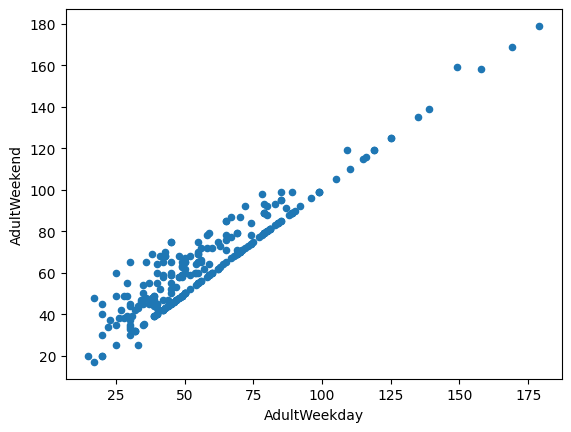

In [171]:
ski_data.plot(x='AdultWeekday', y='AdultWeekend', kind='scatter');

In [172]:
ski_data.loc[ski_data.state == 'Montana', ['AdultWeekend', 'AdultWeekday']]

,AdultWeekend,AdultWeekday
141,42.0,42.0
142,63.0,63.0
143,49.0,49.0
144,48.0,48.0
145,46.0,46.0
146,39.0,39.0
147,50.0,50.0
148,67.0,67.0
149,47.0,47.0
150,39.0,39.0


In [174]:
ski_data[['AdultWeekend', 'AdultWeekday']].isnull().sum()

,0
AdultWeekend,4
AdultWeekday,7


In [175]:
ski_data.drop(columns='AdultWeekday', inplace=True)
ski_data.dropna(subset=['AdultWeekend'], inplace=True)

In [176]:
ski_data.shape

(277, 25)

In [177]:
missingg = pd.concat([ski_data.isnull().sum(axis=1), 100 * ski_data.isnull().mean(axis=1)], axis=1)
missing.columns=['count', '%']
missing.sort_values(by='count', ascending=False).head(10)

,count,%
fastEight,166,50.303030
NightSkiing_ac,143,43.333333
AdultWeekday,54,16.363636
daysOpenLastYear,51,15.454545
TerrainParks,51,15.454545
AdultWeekend,51,15.454545
projectedDaysOpen,47,14.242424
Snow Making_ac,46,13.939394
averageSnowfall,14,4.242424
LongestRun_mi,5,1.515152


In [178]:
missing['%'].unique()

array([ 0.        , 50.3030303 ,  1.21212121, 15.45454545,  1.51515152,
        0.90909091, 13.93939394,  0.3030303 ,  4.24242424, 16.36363636,
       14.24242424, 43.33333333])

In [179]:
ski_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 277 entries, 0 to 329
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               277 non-null    object 
 1   Region             277 non-null    object 
 2   state              277 non-null    object 
 3   summit_elev        277 non-null    int64  
 4   vertical_drop      277 non-null    int64  
 5   base_elev          277 non-null    int64  
 6   trams              277 non-null    int64  
 7   fastSixes          277 non-null    int64  
 8   fastQuads          277 non-null    int64  
 9   quad               277 non-null    int64  
 10  triple             277 non-null    int64  
 11  double             277 non-null    int64  
 12  surface            277 non-null    int64  
 13  total_chairs       277 non-null    int64  
 14  Runs               274 non-null    float64
 15  TerrainParks       233 non-null    float64
 16  LongestRun_mi      272 non-null

In [180]:
ski_data.shape

(277, 25)

In [183]:
output_path = '/content/drive/MyDrive/ski_data_cleaned.csv'
ski_data.to_csv(output_path, index=False)

In [187]:
output_path = '/content/drive/MyDrive/state_summary.csv'
state_summary.to_csv(output_path, index=False)